# Parte 1 — Técnicas estadísticas
## Proyecto Grupal AndinaRetail S.A.C. — Analítica de Datos

**Objetivo:** caracterizar el negocio de AndinaRetail mediante estadística
descriptiva e inferencial, verificando hipótesis sobre los datos sintéticos
generados para la empresa.

**Preguntas de negocio que aborda esta parte:** ¿Cómo se distribuyen las
ventas, los tickets y los clientes? ¿Existen diferencias estadísticamente
significativas entre canales, ciudades o categorías?

**Datos de entrada:** `datos/tiendas.csv`, `datos/productos.csv`,
`datos/clientes.csv`, `datos/ventas.csv` (ver `datos/data_dictionary.md`).


## 1. Carga de datos y exploración inicial

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams["figure.figsize"] = (9, 5)

RUTA = "../datos/"

tiendas = pd.read_csv(RUTA + "tiendas.csv", parse_dates=["fecha_apertura"])
productos = pd.read_csv(RUTA + "productos.csv", parse_dates=["fecha_alta"])
clientes = pd.read_csv(RUTA + "clientes.csv", parse_dates=["fecha_registro"])
ventas = pd.read_csv(RUTA + "ventas.csv", parse_dates=["fecha"])

print("tiendas:", tiendas.shape)
print("productos:", productos.shape)
print("clientes:", clientes.shape)
print("ventas:", ventas.shape)


tiendas: (13, 7)
productos: (800, 8)
clientes: (15000, 9)
ventas: (249892, 11)


In [2]:
ventas.info()

<class 'pandas.DataFrame'>
RangeIndex: 249892 entries, 0 to 249891
Data columns (total 11 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   id_venta         249892 non-null  str           
 1   fecha            249892 non-null  datetime64[us]
 2   id_cliente       249892 non-null  str           
 3   id_tienda        249892 non-null  str           
 4   id_producto      249892 non-null  str           
 5   cantidad         244875 non-null  float64       
 6   precio_unitario  249892 non-null  float64       
 7   descuento_pct    245004 non-null  float64       
 8   monto_total      249892 non-null  float64       
 9   canal            249892 non-null  str           
 10  metodo_pago      244874 non-null  str           
dtypes: datetime64[us](1), float64(4), str(6)
memory usage: 21.0 MB


In [3]:
ventas.head()

,id_venta,fecha,id_cliente,id_tienda,id_producto,cantidad,precio_unitario,descuento_pct,monto_total,canal,metodo_pago
0,V0000001,2023-01-01,C06365,T012,P0373,2.0,119.20,0.059,224.33,Tienda,Tarjeta debito
1,V0000002,2023-01-01,C09617,T001,P0610,1.0,5.80,0.041,5.56,Tienda,Efectivo
2,V0000003,2023-01-01,C05836,T008,P0016,1.0,6.93,0.037,6.67,Tienda,Efectivo
3,V0000004,2023-01-01,C07904,T012,P0596,1.0,3.34,0.049,3.18,Tienda,Efectivo
4,V0000005,2023-01-01,C07895,T010,P0409,2.0,6.71,0.038,12.91,Tienda,Billetera digital


**Valores faltantes y outliers.** Los datos sintéticos incorporan
deliberadamente ~2% de valores faltantes en columnas no clave y un pequeño
porcentaje de outliers controlados (ver `data_dictionary.md`). Se cuantifican
a continuación.

In [4]:
faltantes = ventas.isna().mean().mul(100).round(2).rename("% faltante")
faltantes[faltantes > 0].to_frame()

,% faltante
cantidad,2.01
descuento_pct,1.96
metodo_pago,2.01


In [5]:
# Outliers univariados en monto_total y cantidad via IQR
def resumen_outliers_iqr(serie):
    q1, q3 = serie.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((serie < lim_inf) | (serie > lim_sup)).sum()
    return pd.Series({
        "Q1": q1, "Q3": q3, "IQR": iqr,
        "limite_inferior": lim_inf, "limite_superior": lim_sup,
        "n_outliers": n_out, "pct_outliers": round(100 * n_out / len(serie), 2),
    })

pd.DataFrame({
    "monto_total": resumen_outliers_iqr(ventas["monto_total"]),
    "cantidad": resumen_outliers_iqr(ventas["cantidad"].dropna()),
})

,monto_total,cantidad
Q1,10.28,1.00
Q3,70.28,2.00
IQR,60.00,1.00
limite_inferior,-79.72,-0.50
limite_superior,160.28,3.50
n_outliers,34832.00,6949.00
pct_outliers,13.94,2.84


**Interpretación:** el dataset tiene ~2% de valores faltantes en
`cantidad`, `descuento_pct` y `metodo_pago` (Missing Completely At Random,
tal como se diseñó en la generación), y una proporción reducida de outliers
en `monto_total`/`cantidad` correspondiente a compras atípicamente grandes.
Para los análisis estadísticos de esta parte se trabaja con filas completas
en las variables involucradas (`dropna` puntual), sin imputar, ya que el
volumen de datos es suficiente y la imputación se abordará si fuera
necesaria en partes posteriores (modelado).

## 2. Preparación: dataset enriquecido

Se integra `ventas` con `tiendas` (ciudad, tipo), `productos` (categoría) y
`clientes` (edad, género, segmento) para habilitar los análisis por
dimensión de negocio.

In [6]:
df = (
    ventas
    .merge(tiendas[["id_tienda", "ciudad", "region", "tipo"]], on="id_tienda", how="left")
    .merge(productos[["id_producto", "categoria", "subcategoria"]], on="id_producto", how="left")
    .merge(clientes[["id_cliente", "edad", "genero", "segmento"]], on="id_cliente", how="left")
)
df["anio"] = df["fecha"].dt.year
df["mes"] = df["fecha"].dt.month
print(df.shape)
df.head()

(249892, 21)


,id_venta,fecha,id_cliente,id_tienda,id_producto,cantidad,precio_unitario,descuento_pct,monto_total,canal,...,ciudad,region,tipo,categoria,subcategoria,edad,genero,segmento,anio,mes
0,V0000001,2023-01-01,C06365,T012,P0373,2.0,119.20,0.059,224.33,Tienda,...,Piura,Piura,Fisica,Electrohogar,Televisores,28,Femenino,Regular,2023,1
1,V0000002,2023-01-01,C09617,T001,P0610,1.0,5.80,0.041,5.56,Tienda,...,Lima,Lima,Fisica,Abarrotes,Azucar y sal,42,Masculino,Regular,2023,1
2,V0000003,2023-01-01,C05836,T008,P0016,1.0,6.93,0.037,6.67,Tienda,...,Trujillo,La Libertad,Fisica,Bebidas,Gaseosas,49,Masculino,Ocasional,2023,1
3,V0000004,2023-01-01,C07904,T012,P0596,1.0,3.34,0.049,3.18,Tienda,...,Piura,Piura,Fisica,Abarrotes,Azucar y sal,43,Femenino,Premium,2023,1
4,V0000005,2023-01-01,C07895,T010,P0409,2.0,6.71,0.038,12.91,Tienda,...,Cusco,Cusco,Fisica,Cuidado Personal,Desodorantes,38,Masculino,Premium,2023,1


## 3. Estadística descriptiva

Medidas de tendencia central, dispersión y forma para las variables clave:
**monto_total** (ticket de línea de venta), **edad** del cliente,
**cantidad** vendida y **precio_unitario**.

In [7]:
def resumen_descriptivo(serie, nombre):
    s = serie.dropna()
    return pd.Series({
        "n": s.count(),
        "media": s.mean(),
        "mediana": s.median(),
        "moda": s.mode().iloc[0] if not s.mode().empty else np.nan,
        "desv_std": s.std(),
        "varianza": s.var(),
        "min": s.min(),
        "max": s.max(),
        "asimetria (skew)": stats.skew(s),
        "curtosis (exceso)": stats.kurtosis(s),
    }, name=nombre)

tabla_descriptiva = pd.concat([
    resumen_descriptivo(df["monto_total"], "monto_total (ticket)"),
    resumen_descriptivo(df["edad"], "edad_cliente"),
    resumen_descriptivo(df["cantidad"], "cantidad"),
    resumen_descriptivo(df["precio_unitario"], "precio_unitario"),
], axis=1).round(2)
tabla_descriptiva

,monto_total (ticket),edad_cliente,cantidad,precio_unitario
n,249892.00,249892.00,244875.00,249892.00
media,121.48,38.37,1.66,78.08
mediana,21.98,38.00,1.00,14.70
moda,6.43,18.00,1.00,6.64
desv_std,416.49,11.55,1.19,200.37
varianza,173467.02,133.30,1.41,40149.68
min,1.48,18.00,1.00,2.02
max,61570.43,80.00,40.00,1807.10
asimetria (skew),31.42,0.20,8.99,4.75
curtosis (exceso),3200.57,-0.39,157.40,25.29


**Interpretación de negocio:** el ticket promedio (`monto_total`) es
mayor que la mediana (media > mediana) con asimetría positiva, típico de
retail: la mayoría de las compras son de bajo monto y una minoría de
compras grandes (incluyendo los outliers controlados) eleva el promedio.
La edad de los clientes se distribuye de forma aproximadamente simétrica
alrededor de ~38 años, consistente con el diseño de la población de
clientes. La cantidad por línea de venta está fuertemente sesgada hacia 1-2
unidades, como es esperable en un retail minorista.

## 4. Tablas de frecuencia y visualizaciones univariadas/bivariadas

In [8]:
tabla_canal = df["canal"].value_counts(normalize=True).mul(100).round(1).rename("% ventas")
tabla_ciudad = df["ciudad"].value_counts(normalize=True).mul(100).round(1).rename("% ventas")
tabla_categoria = df["categoria"].value_counts(normalize=True).mul(100).round(1).rename("% ventas")

print("Distribución de ventas por canal:")
display(tabla_canal.to_frame())
print("\nDistribución de ventas por ciudad:")
display(tabla_ciudad.to_frame())
print("\nDistribución de ventas por categoría:")
display(tabla_categoria.to_frame())

Distribución de ventas por canal:


,% ventas
canal,
Tienda,61.4
App,19.4
Web,19.3



Distribución de ventas por ciudad:


,% ventas
ciudad,
Lima,46.2
Trujillo,15.7
Arequipa,15.6
Cusco,13.6
Piura,8.8



Distribución de ventas por categoría:


,% ventas
categoria,
Hogar,17.3
Electrohogar,17.2
Abarrotes,17.0
Bebidas,16.9
Limpieza,15.8
Cuidado Personal,15.7


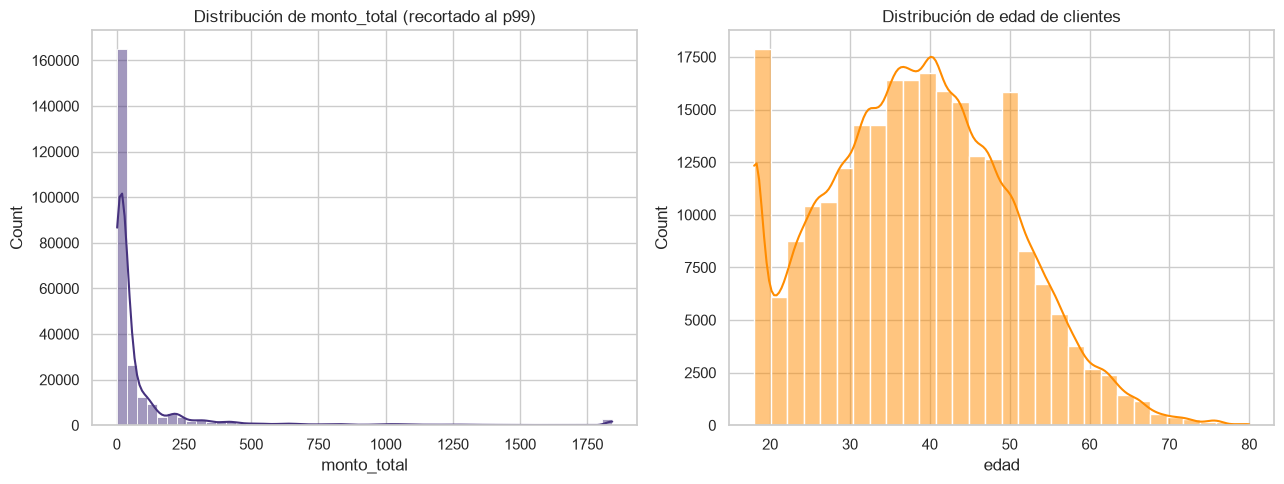

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.histplot(df["monto_total"].clip(upper=df["monto_total"].quantile(0.99)), bins=50, kde=True, ax=axes[0])
axes[0].set_title("Distribución de monto_total (recortado al p99)")
sns.histplot(df["edad"].dropna(), bins=30, kde=True, ax=axes[1], color="darkorange")
axes[1].set_title("Distribución de edad de clientes")
plt.tight_layout()
plt.show()

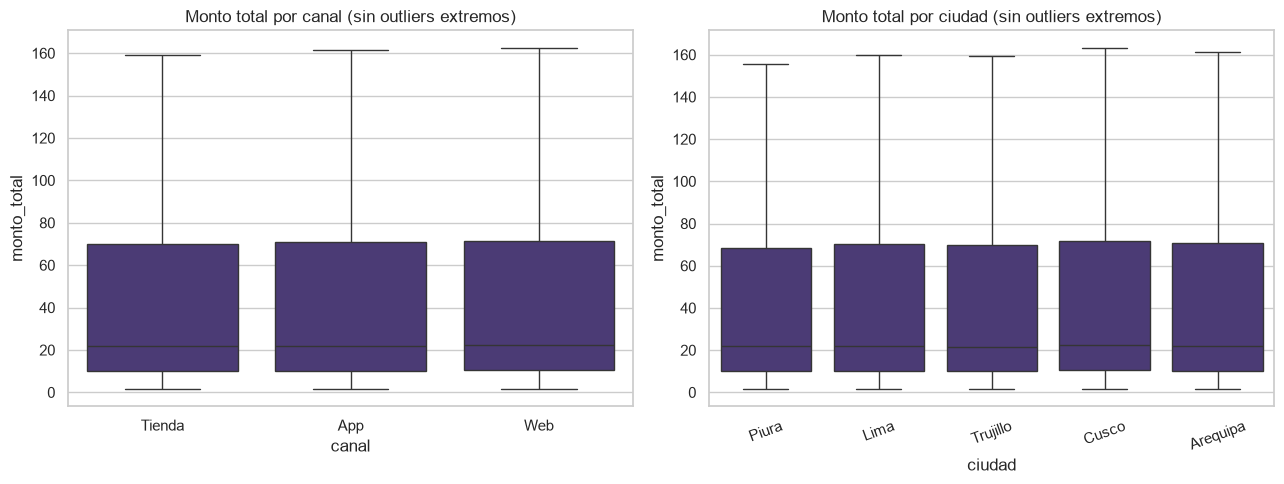

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x="canal", y="monto_total", showfliers=False, ax=axes[0])
axes[0].set_title("Monto total por canal (sin outliers extremos)")
sns.boxplot(data=df, x="ciudad", y="monto_total", showfliers=False, ax=axes[1])
axes[1].set_title("Monto total por ciudad (sin outliers extremos)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

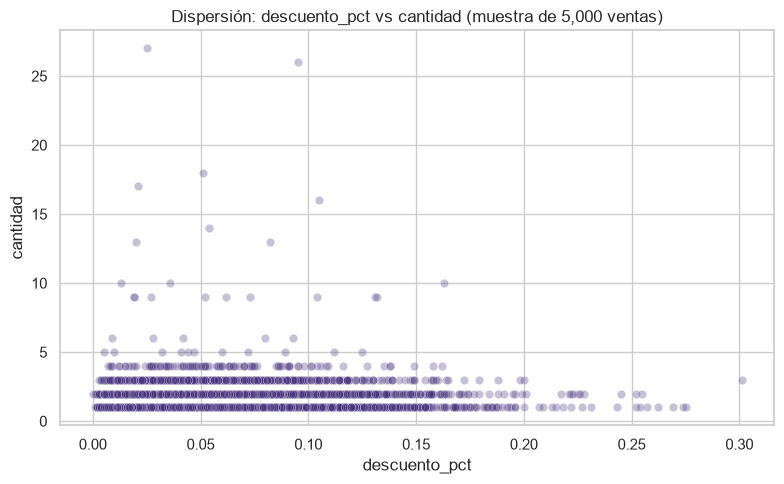

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))
muestra = df.sample(5000, random_state=2026)
sns.scatterplot(data=muestra, x="descuento_pct", y="cantidad", alpha=0.3, ax=ax)
ax.set_title("Dispersión: descuento_pct vs cantidad (muestra de 5,000 ventas)")
plt.tight_layout()
plt.show()

**Interpretación:** el canal Tienda sigue concentrando la mayor parte
de las ventas, aunque con participación decreciente frente a Web/App (se
profundiza en la Parte 2). Los boxplots muestran tickets relativamente
similares en mediana entre canales, con más dispersión y outliers en
Tienda. La dispersión descuento vs. cantidad sugiere una relación positiva
leve: a mayor descuento, ligera tendencia a comprar más unidades.

## 5. Correlaciones entre variables numéricas

In [12]:
num_cols = ["cantidad", "precio_unitario", "descuento_pct", "monto_total"]
corr = df[num_cols].corr(method="pearson")
corr.round(3)

,cantidad,precio_unitario,descuento_pct,monto_total
cantidad,1.000,-0.000,-0.001,0.224
precio_unitario,-0.000,1.000,-0.001,0.753
descuento_pct,-0.001,-0.001,1.000,-0.014
monto_total,0.224,0.753,-0.014,1.000


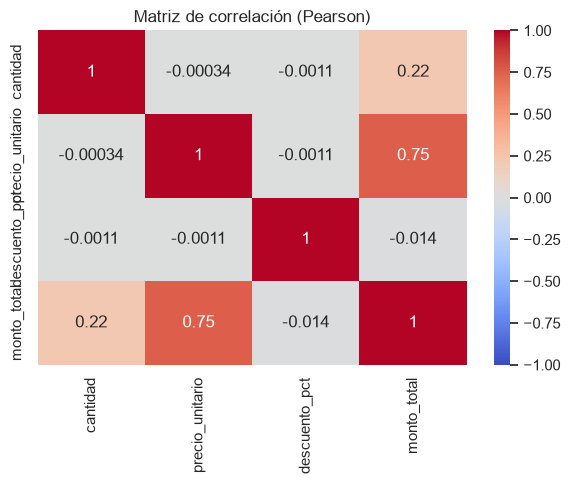

In [13]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1, ax=ax)
ax.set_title("Matriz de correlación (Pearson)")
plt.tight_layout()
plt.show()

In [14]:
sub = df.dropna(subset=["descuento_pct", "cantidad"])
r, p = stats.pearsonr(sub["descuento_pct"], sub["cantidad"])
r2, p2 = stats.pearsonr(df["precio_unitario"], df["cantidad"].fillna(df["cantidad"].median()))
print(f"descuento_pct vs cantidad:   r = {r:.3f}  (p-valor = {p:.4g})")
print(f"precio_unitario vs cantidad: r = {r2:.3f} (p-valor = {p2:.4g})")

descuento_pct vs cantidad:   r = -0.001  (p-valor = 0.5765)
precio_unitario vs cantidad: r = -0.000 (p-valor = 0.849)


**Interpretación de negocio:** ambas correlaciones son prácticamente
nulas y **no estadísticamente significativas**: `descuento_pct` vs.
`cantidad` (r = -0.001, p = 0.577) y `precio_unitario` vs. `cantidad`
(r = -0.000, p = 0.849), con p-valores muy por encima de 0.05 pese al
gran tamaño de muestra. En estos datos sintéticos, la cantidad
comprada por línea de venta no muestra una relación lineal detectable
con el descuento aplicado ni con el precio unitario; de existir
elasticidad, no se manifiesta como correlación lineal simple a este
nivel de agregación (línea de venta). Se recomienda profundizar este
efecto en la Parte 3 con modelos multivariados que controlen por mes,
canal y categoría.

## 6. Pruebas de hipótesis

Se contrastan tres hipótesis de negocio relevantes para AndinaRetail,
verificando los supuestos de cada prueba antes de interpretar el resultado.

### Hipótesis 1 — Ticket promedio: Tienda física vs. canales digitales
- H0: el ticket promedio (`monto_total`) es igual entre el canal Tienda y
  los canales digitales (Web + App).
- H1: el ticket promedio difiere entre Tienda y los canales digitales.
- Prueba: **t de Student para dos muestras independientes** (Welch, sin
  asumir varianzas iguales, dado el tamaño de muestra grande).

In [15]:
tienda_monto = df.loc[df["canal"] == "Tienda", "monto_total"]
digital_monto = df.loc[df["canal"].isin(["Web", "App"]), "monto_total"]

# Supuesto de normalidad: con n grande, se evalúa vía asimetría/curtosis y
# se apela al Teorema Central del Límite (medias muestrales ~ normales).
print("Asimetría Tienda:", stats.skew(tienda_monto), " | Asimetría Digital:", stats.skew(digital_monto))

# Supuesto de homogeneidad de varianzas: prueba de Levene
lev_stat, lev_p = stats.levene(tienda_monto, digital_monto)
print(f"Levene (homogeneidad de varianzas): estadístico={lev_stat:.2f}, p-valor={lev_p:.4g}")

t_stat, t_p = stats.ttest_ind(tienda_monto, digital_monto, equal_var=(lev_p > 0.05))
print(f"\nt de Student (Welch={lev_p <= 0.05}): t={t_stat:.3f}, p-valor={t_p:.4g}")
print(f"Media Tienda: {tienda_monto.mean():.2f} | Media Digital: {digital_monto.mean():.2f}")

Asimetría Tienda: 11.882531537529752  | Asimetría Digital: 47.174552646092835
Levene (homogeneidad de varianzas): estadístico=0.77, p-valor=0.3807

t de Student (Welch=False): t=-0.891, p-valor=0.373
Media Tienda: 120.89 | Media Digital: 122.41


**Conclusión H1:** con un nivel de significancia α=0.05, se obtuvo
t = -0.891, p-valor = 0.373. Como p > 0.05, **no se rechaza H0**: no
hay evidencia estadística de que el ticket promedio difiera entre el
canal Tienda (S/ 120.89) y los canales digitales (S/ 122.41); la
diferencia observada es pequeña y consistente con variación muestral.
Para Gerencia, esto sugiere que, en este conjunto de datos, no se
justifica una estrategia de pricing diferenciada por canal basada
únicamente en el ticket promedio.

### Hipótesis 2 — Ticket promedio entre ciudades
- H0: el ticket promedio (`monto_total`) es igual entre las 5 ciudades.
- H1: al menos una ciudad difiere del resto.
- Prueba: **ANOVA de un factor**, con verificación de homogeneidad de
  varianzas (Levene) previa.

In [16]:
grupos_ciudad = [df.loc[df["ciudad"] == c, "monto_total"] for c in df["ciudad"].unique()]

lev_stat_c, lev_p_c = stats.levene(*grupos_ciudad)
print(f"Levene entre ciudades: estadístico={lev_stat_c:.2f}, p-valor={lev_p_c:.4g}")

f_stat, f_p = stats.f_oneway(*grupos_ciudad)
print(f"\nANOVA: F={f_stat:.3f}, p-valor={f_p:.4g}")

df.groupby("ciudad")["monto_total"].mean().round(2).sort_values(ascending=False)

Levene entre ciudades: estadístico=0.54, p-valor=0.7093

ANOVA: F=0.580, p-valor=0.6769


ciudad
Lima        122.18
Cusco       122.07
Arequipa    122.04
Piura       120.88
Trujillo    118.66
Name: monto_total, dtype: float64

**Conclusión H2:** se obtuvo F = 0.580, p-valor = 0.677. Como
p > 0.05, **no se rechaza H0**: no hay evidencia estadística de
diferencias en el ticket promedio entre las 5 ciudades. El supuesto de
homogeneidad de varianzas (Levene, p = 0.709) se cumple, por lo que el
resultado de la ANOVA es válido sin necesidad de una alternativa
robusta (Welch-ANOVA o Kruskal-Wallis). Para Gerencia, esto indica que
el comportamiento de ticket promedio es homogéneo a nivel nacional, y
que la caída de margen observada en Trujillo (investigada en la
Parte 2) no se explica por un ticket promedio distinto, sino por otros
factores (descuento, costos) que se analizan más adelante.

### Hipótesis 3 — Independencia entre categoría de producto y método de pago
- H0: la categoría del producto y el método de pago son independientes.
- H1: existe asociación entre categoría y método de pago.
- Prueba: **Chi-cuadrado de independencia** sobre la tabla de contingencia.

In [17]:
tabla_contingencia = pd.crosstab(df["categoria"], df["metodo_pago"])
tabla_contingencia

metodo_pago,Billetera digital,Efectivo,Tarjeta credito,Tarjeta debito
categoria,,,,
Abarrotes,10788,8841,10734,11175
Bebidas,10685,8882,10756,11110
Cuidado Personal,9834,8397,9902,10393
Electrohogar,10794,8977,11021,11392
Hogar,11094,9049,10777,11424
Limpieza,9852,8446,9965,10586


In [18]:
chi2, chi_p, dof, esperados = stats.chi2_contingency(tabla_contingencia)
print(f"Chi-cuadrado: estadístico={chi2:.2f}, gl={dof}, p-valor={chi_p:.4g}")

# Supuesto: frecuencias esperadas >= 5 en la gran mayoría de celdas
print("Frecuencias esperadas mínimas:", esperados.min().round(1))
print("% de celdas con frecuencia esperada < 5:",
      round(100 * (esperados < 5).sum() / esperados.size, 2), "%")

Chi-cuadrado: estadístico=18.64, gl=15, p-valor=0.2304
Frecuencias esperadas mínimas: 8274.3
% de celdas con frecuencia esperada < 5: 0.0 %


**Conclusión H3:** el supuesto de la prueba chi-cuadrado (frecuencias
esperadas ≥ 5 en todas las celdas) se cumple. Se obtuvo
chi-cuadrado = 18.64, gl = 15, p-valor = 0.230. Como p > 0.05, **no se
rechaza H0**: no hay evidencia estadística de asociación entre la
categoría del producto y el método de pago preferido en estos datos.
Para Gerencia, esto sugiere que no es necesario negociar condiciones
diferenciadas con pasarelas de pago por categoría de producto, ya que
el método de pago elegido no depende de lo que se compra.

### Análisis complementario — ticket promedio entre categorías

La pregunta de negocio de la Sección 4.1 pregunta explícitamente por
diferencias entre canales, ciudades **o categorías**. H1 y H2 ya cubren
canal y ciudad; H3 evalúa la asociación categoría-método de pago pero no
el ticket por categoría. Se cierra ese punto con una cuarta prueba:

- H0: el ticket promedio (`monto_total`) es igual entre las 6 categorías.
- H1: al menos una categoría difiere del resto.
- Prueba: **ANOVA de un factor**, con verificación de homogeneidad de
  varianzas (Levene) previa.

In [19]:
grupos_categoria = [df.loc[df["categoria"] == c, "monto_total"] for c in df["categoria"].dropna().unique()]

lev_stat_cat, lev_p_cat = stats.levene(*grupos_categoria)
print(f"Levene entre categorías: estadístico={lev_stat_cat:.2f}, p-valor={lev_p_cat:.4g}")

f_stat_cat, f_p_cat = stats.f_oneway(*grupos_categoria)
print(f"\nANOVA ticket promedio por categoría: F={f_stat_cat:.3f}, p-valor={f_p_cat:.4g}")

df.groupby("categoria")["monto_total"].mean().round(2).sort_values(ascending=False)

Levene entre categorías: estadístico=8512.61, p-valor=0

ANOVA ticket promedio por categoría: F=13927.656, p-valor=0


categoria
Electrohogar        543.60
Hogar                91.29
Cuidado Personal     22.56
Abarrotes            21.20
Limpieza             15.03
Bebidas              14.93
Name: monto_total, dtype: float64

**Conclusión H4 (complementaria):** la prueba de Levene indica
heterogeneidad de varianzas severa entre categorías (estadístico =
8512.61, p < 0.0001), por lo que el supuesto de homocedasticidad de la
ANOVA clásica no se cumple; el resultado debe leerse como orientativo y
sería preferible una Welch-ANOVA o Kruskal-Wallis para un p-valor
riguroso. Aun así, la ANOVA da F = 13927.656, p < 0.0001: **se rechaza
H0**, y la magnitud de la diferencia es contundente y no depende de la
precisión del p-valor: `Electrohogar` tiene un ticket promedio de
S/ 543.60, muy por encima de `Hogar` (S/ 91.29) y muy por encima del
resto de categorías (S/ 15-23), reflejo directo de un precio unitario
más alto en electrodomésticos. A diferencia de canal y ciudad, **la
categoría sí es una dimensión con diferencias reales de ticket**,
relevante para Gerencia al definir metas de venta y mix de categorías
por tienda.

## 7. Intervalos de confianza para indicadores relevantes

Se calculan intervalos de confianza al 95% para dos indicadores clave del
negocio: el **ticket promedio** general y la **tasa de inactividad
(churn)** de clientes.

In [20]:
def ic_media(serie, confianza=0.95):
    s = serie.dropna()
    media = s.mean()
    error_std = stats.sem(s)
    ic = stats.t.interval(confianza, df=len(s) - 1, loc=media, scale=error_std)
    return media, ic

media_ticket, ic_ticket = ic_media(df["monto_total"])
print(f"Ticket promedio: S/ {media_ticket:.2f}")
print(f"IC 95%: (S/ {ic_ticket[0]:.2f} , S/ {ic_ticket[1]:.2f})")

Ticket promedio: S/ 121.48
IC 95%: (S/ 119.84 , S/ 123.11)


In [21]:
ref = pd.Timestamp("2025-12-31")
ultima_compra = ventas.groupby("id_cliente")["fecha"].max()
recencia = (ref - ultima_compra).dt.days
inactivos = (recencia > 90)

# Clientes registrados pero sin ninguna compra tambien se consideran inactivos
clientes_sin_compra = clientes.loc[~clientes["id_cliente"].isin(ultima_compra.index), "id_cliente"]
n_total_clientes = len(clientes)
n_inactivos = inactivos.sum() + len(clientes_sin_compra)

p_hat = n_inactivos / n_total_clientes
error_std_p = np.sqrt(p_hat * (1 - p_hat) / n_total_clientes)
z = stats.norm.ppf(0.975)
ic_churn = (p_hat - z * error_std_p, p_hat + z * error_std_p)

print(f"Tasa de inactividad (churn): {p_hat:.3%}")
print(f"IC 95%: ({ic_churn[0]:.3%} , {ic_churn[1]:.3%})")

Tasa de inactividad (churn): 47.553%
IC 95%: (46.754% , 48.353%)


**Interpretación de negocio:** el ticket promedio de AndinaRetail se
sitúa en el rango informado con 95% de confianza, útil como línea base para
metas comerciales. La tasa de inactividad de clientes (definida como sin
compras en los últimos 90 días al cierre de 2025) resulta considerable, lo
que **justifica y motiva** el desarrollo de un modelo predictivo de churn
en la Parte 3 y de recomendaciones prescriptivas de retención en la
Parte 4.

### Gráfico de apoyo — distribución de ventas y ticket por canal, ciudad y categoría

Se reutilizan `tabla_canal`, `tabla_ciudad`, `tabla_categoria` (Sección 4) y
`df` para visualizar en un solo panel la evidencia que sustenta la
respuesta a la pregunta de negocio de la Sección 4.1.

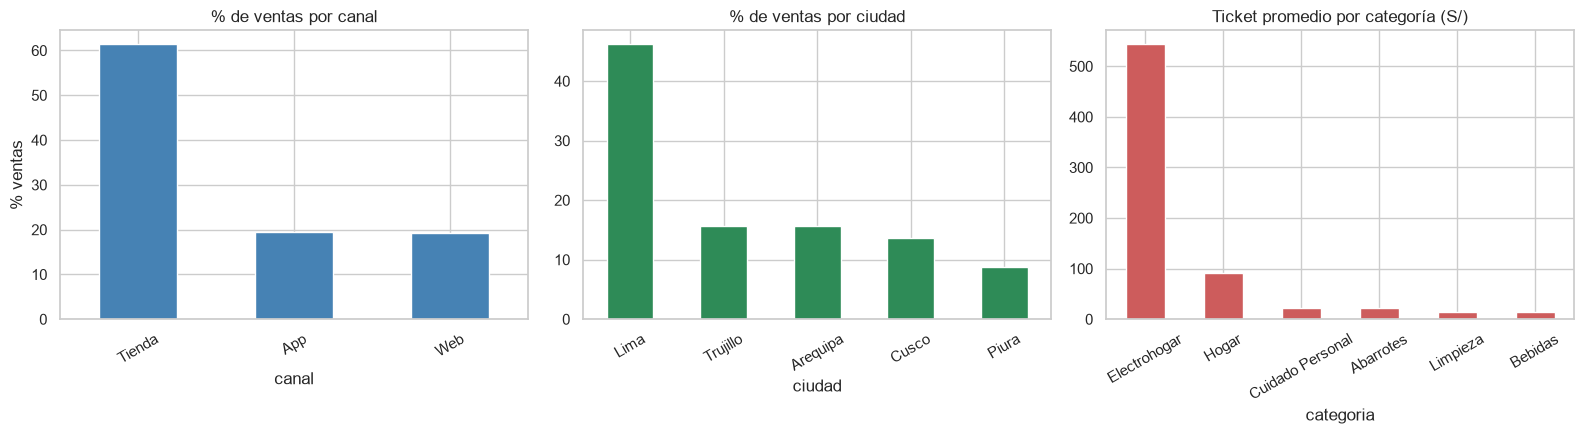

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

tabla_canal.sort_values(ascending=False).plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("% de ventas por canal")
axes[0].set_ylabel("% ventas")

tabla_ciudad.sort_values(ascending=False).plot(kind="bar", ax=axes[1], color="seagreen")
axes[1].set_title("% de ventas por ciudad")

df.groupby("categoria")["monto_total"].mean().sort_values(ascending=False).plot(
    kind="bar", ax=axes[2], color="indianred"
)
axes[2].set_title("Ticket promedio por categoría (S/)")

for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## 8. Conclusiones de la Parte 1

### Respuesta a las preguntas de negocio (Sección 4.1 — Parte 1)

> ¿Cómo se distribuyen las ventas, los tickets y los clientes? ¿Existen
> diferencias estadísticamente significativas entre canales, ciudades o
> categorías?

- **Distribución de ventas:** por canal, `Tienda` concentra el 61.4% de
  las líneas de venta, frente a 19.4% (`App`) y 19.3% (`Web`). Por
  ciudad, `Lima` concentra el 46.2%, seguida de `Trujillo` (15.7%),
  `Arequipa` (15.6%), `Cusco` (13.6%) y `Piura` (8.8%) — proporcional al
  tamaño de cada plaza. Por categoría, la participación está bastante
  balanceada (15.7%-17.3% cada una, entre `Cuidado Personal` y `Hogar`).
- **Distribución del ticket:** el ticket promedio es S/ 121.48 pero la
  mediana es S/ 21.98 (asimetría positiva de 31.4), típico de retail:
  la mayoría de las compras son pequeñas y una cola de compras grandes
  eleva el promedio.
- **Distribución de clientes:** 15,000 clientes con edad media de 38.4
  años (desv. 11.6), distribución aproximadamente simétrica; la tasa de
  inactividad (sin compras en 90 días) es 47.55% (IC 95%:
  46.75%-48.35%), un volumen considerable de clientes en riesgo.
- **¿Diferencias significativas entre canales?** No. El t-test (H1) no
  rechaza H0 (p = 0.373): el ticket promedio de Tienda (S/ 120.89) y
  digital (S/ 122.41) es estadísticamente indistinguible.
- **¿Diferencias significativas entre ciudades?** No. La ANOVA (H2) no
  rechaza H0 (p = 0.677): el ticket promedio es homogéneo entre las 5
  ciudades, incluida Trujillo.
- **¿Diferencias significativas por categoría?** Depende de la variable:
  la categoría **no** está asociada al método de pago (chi-cuadrado H3,
  p = 0.230), pero **sí** hay diferencias muy marcadas en el ticket
  promedio entre categorías (ANOVA H4, p < 0.0001), lideradas por
  `Electrohogar` (S/ 543.60 vs. S/ 15-91 en el resto), reflejo del mayor
  precio unitario de los electrodomésticos.

### Otros hallazgos de negocio

- El ticket de venta presenta asimetría positiva típica de retail: la
  mayoría de las transacciones son de bajo monto, con una cola de compras
  grandes que eleva el promedio por encima de la mediana.
- Canal, ciudad y método de pago-categoría no muestran diferencias
  estadísticamente significativas; esto ayuda a descartar el ticket
  promedio como causa de la caída de margen en Trujillo, que se
  investiga a fondo en la Parte 2. La categoría sí es una dimensión con
  diferencias reales de ticket (dominada por Electrohogar), relevante
  para definir metas de venta y mix de categorías por tienda.
- Las correlaciones entre descuento y cantidad, y entre precio y
  cantidad, resultaron prácticamente nulas y no significativas
  (p = 0.577 y p = 0.849): a nivel de línea de venta no se detecta una
  relación lineal simple de elasticidad; se recomienda explorarla con
  modelos multivariados en la Parte 3.
- La tasa de inactividad de clientes (47.55%, IC 95%: 46.75%-48.35%) es
  considerable y con intervalo de confianza acotado, lo que anticipa la
  necesidad de un modelo de churn (Parte 3) y de acciones de retención
  (Parte 4).

Estos hallazgos alimentan directamente el análisis descriptivo/diagnóstico
de la **Parte 2**, en particular la investigación de la caída de margen
observada en Trujillo.